In [1]:
import pandas as pd
import requests
from io import StringIO

In [2]:
df = pd.read_csv(StringIO(requests.get('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day42-outlier-removal-using-zscore/placement.csv').text))
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [3]:
df.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

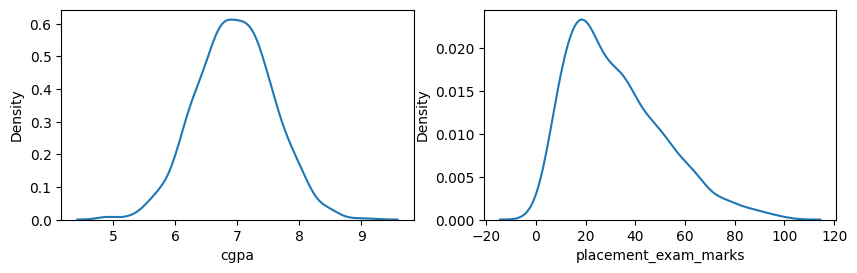

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.subplot(221)
sns.kdeplot(df['cgpa'])

plt.subplot(222)
sns.kdeplot(df['placement_exam_marks'])

In [16]:
per25 = df['placement_exam_marks'].quantile(0.25)
per75 = df['placement_exam_marks'].quantile(0.75)

In [19]:
iqr = per75 - per25
lower = per25 - 1.5 * iqr
upper = per75 + 1.5 * iqr

## trimming

In [31]:
new_df = df[(df['placement_exam_marks'] >= lower) & (df['placement_exam_marks'] <= upper)]
new_df['placement_exam_marks']

0      26.0
1      38.0
2      40.0
3       8.0
4      17.0
       ... 
995    44.0
996    65.0
997    34.0
998    46.0
999    10.0
Name: placement_exam_marks, Length: 985, dtype: float64

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

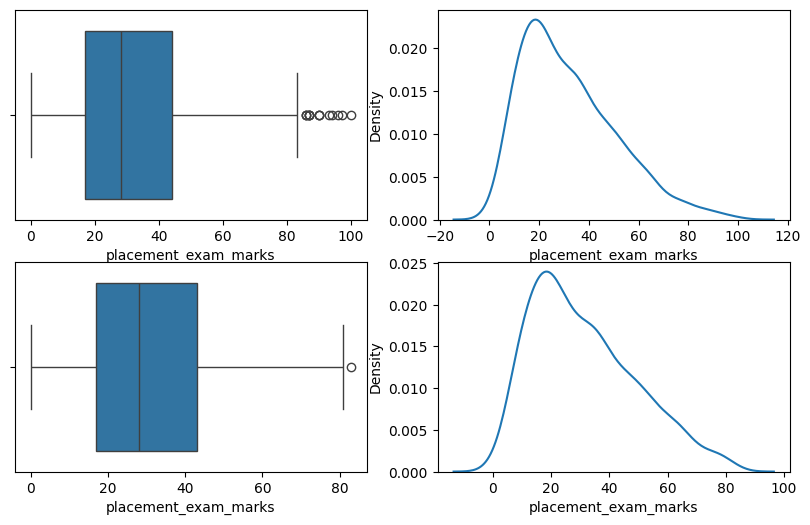

In [36]:
plt.figure(figsize=(10, 6))
plt.subplot(221)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(222)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(223)
sns.boxplot(x = new_df['placement_exam_marks'])

plt.subplot(224)
sns.kdeplot(new_df['placement_exam_marks'])

## capping

In [37]:
import numpy as np
new_df = df.copy()
new_df['placement_exam_marks'] = np.where(
    df['placement_exam_marks'] > upper,
    upper,
    np.where(
        df['placement_exam_marks'] < lower,
        lower,
        df['placement_exam_marks']
    )
)
new_df.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

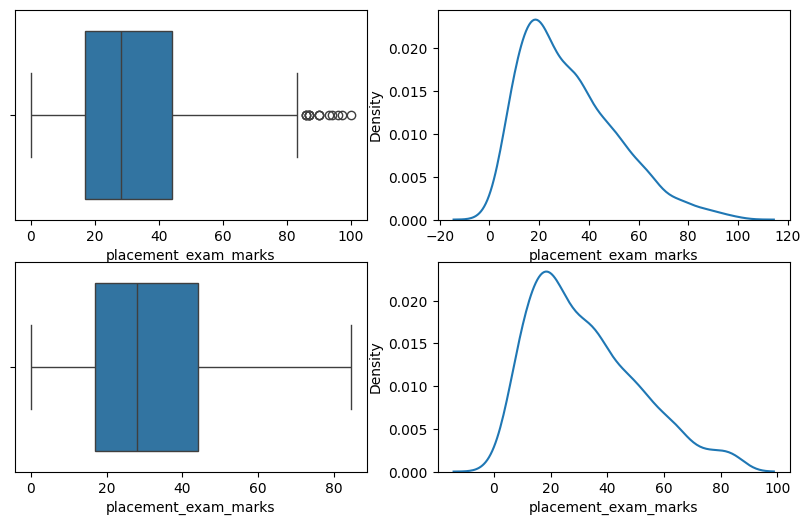

In [40]:
plt.figure(figsize=(10, 6))
plt.subplot(221)
sns.boxplot(x = df['placement_exam_marks'])

plt.subplot(222)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(223)
sns.boxplot(x = new_df['placement_exam_marks'])

plt.subplot(224)
sns.kdeplot(new_df['placement_exam_marks'])